## ICBA. Placeholder title

In [30]:
import pandas as pd
from pathlib import Path

df = pd.DataFrame()

df = pd.read_csv('../data/processed/masskara/analysis/master.csv')

df.head(1)

,date_collected,trend_search_score,flight_fest_min_price,flight_fest_max_price,flight_fest_median_price,flight_fest_mean_price,flight_fest_quote_count,flight_rolling_min_price,flight_rolling_max_price,flight_rolling_median_price,...,hotel_rolling_quote_count,flight_price_premium,hotel_price_premium,trend_velocity_7d,trend_score_lag_1d,trend_score_lag_2d,trend_score_lag_3d,flight_median_change_1d,hotel_median_change_1d,days_to_festival
0,2026-09-02,82,1936,2731,2234.0,2317.230769,13,2900,5643,3684.0,...,20,0.606406,1.122834,NaN,NaN,NaN,NaN,NaN,NaN,37


In [31]:
# convert date from str to datetime
# display(df.dtypes)
df['date_collected'] = pd.to_datetime(df['date_collected'])
# display(df.dtypes)

In [ ]:
weekly_df = df.set_index('date_collected').resample('W').agg({
    'trend_search_score':'sum',
    'flight_fest_mean_price': 'mean'
}).reset_index()

In [33]:
weekly_df

,date_collected,trend_search_score,flight_fest_mean_price
0,2026-09-06,297,2373.661538
1,2026-09-13,397,2691.615385
2,2026-09-20,370,2908.318681
3,2026-09-27,460,3113.417582


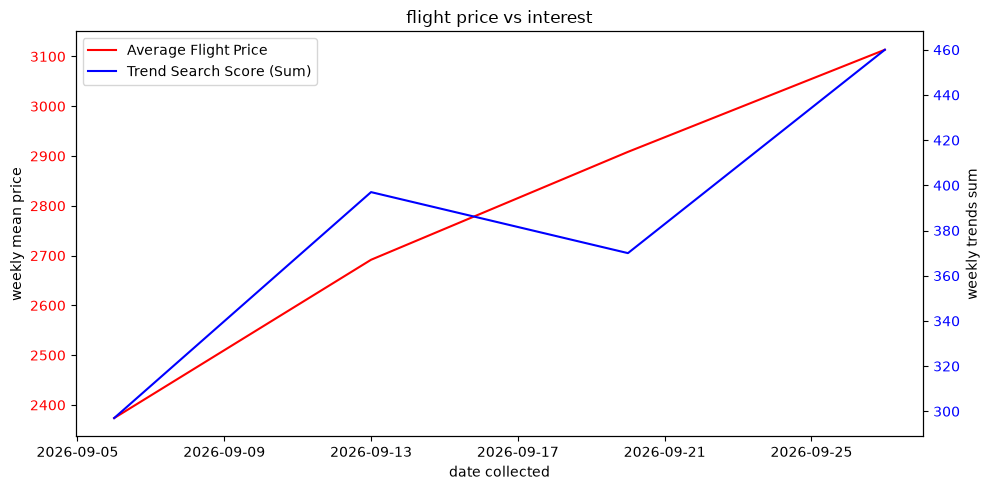

In [34]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['date_collected'], 
    weekly_df['flight_fest_mean_price'], 
    label='Average Flight Price', 
    color='red')
ax1.set_xlabel('date collected')
ax1.set_ylabel('weekly mean price')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()

line2 = ax2.plot(
    weekly_df['date_collected'], 
    weekly_df['trend_search_score'],
    label='Trend Search Score (Sum)',
    color='blue')
ax2.set_ylabel('weekly trends sum')
ax2.tick_params(axis='y', labelcolor='blue')

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('flight price vs interest')
fig.tight_layout()
plt.show()